# Class item count — After_label/labels_19-25,27,29_06

Counts number of instances (YOLOseg polygons) per class.
Each non-empty line in a `.txt` label file = one instance. First token = class id (0-based).
Class names come from `6class.txt` (line 1 = class id 0, ... line 6 = class id 5).

In [1]:
from pathlib import Path
from collections import Counter
import pandas as pd

ROOT = Path.cwd().parent  # Analysis -> DataSet
LABEL_DIR = ROOT / 'After_label' / 'labels_19-25,27,29_06'
CLASS_FILE = ROOT / '6class.txt'
assert LABEL_DIR.is_dir(), LABEL_DIR
assert CLASS_FILE.is_file(), CLASS_FILE

In [2]:
# class id -> name (file line order = 0-based id)
names = [l.strip() for l in CLASS_FILE.read_text().splitlines() if l.strip()]
id2name = {i: n for i, n in enumerate(names)}
id2name

{0: 'comtam_dust',
 1: 'comtam_stain',
 2: 'comtam_x',
 3: 'scratch_dent',
 4: 'scratch_line',
 5: 'other'}

In [3]:
# count instances per class
counts = Counter()
files = 0
empty = 0
for txt in LABEL_DIR.glob('*.txt'):
    files += 1
    lines = [ln for ln in txt.read_text().splitlines() if ln.strip()]
    if not lines:
        empty += 1
    for ln in lines:
        cid = int(ln.split()[0])
        counts[cid] += 1

print(f'label files: {files}  (empty: {empty})')
print(f'total instances: {sum(counts.values())}')

label files: 774  (empty: 117)
total instances: 1527


In [4]:
# table: every class from 6class.txt, 0 if absent
rows = []
for cid, name in id2name.items():
    rows.append({'class_id': cid, 'class_name': name, 'count': counts.get(cid, 0)})
# flag any class id present in labels but missing from 6class.txt
for cid in sorted(counts):
    if cid not in id2name:
        rows.append({'class_id': cid, 'class_name': f'UNKNOWN_{cid}', 'count': counts[cid]})

df = pd.DataFrame(rows).sort_values('class_id').reset_index(drop=True)
total = df['count'].sum()
df['pct'] = (df['count'] / total * 100).round(2)
df

,class_id,class_name,count,pct
0,0,comtam_dust,811,53.11
1,1,comtam_stain,56,3.67
2,2,comtam_x,396,25.93
3,3,scratch_dent,39,2.55
4,4,scratch_line,25,1.64
5,5,other,200,13.10


In [5]:
# save csv next to this notebook
out = Path.cwd() / 'class_counts_19-25,27,29_06.csv'
df.to_csv(out, index=False)
print('saved:', out)

saved: c:\Users\7364239\Desktop\project\DataSet\Analysis\class_counts_19-25,27,29_06.csv


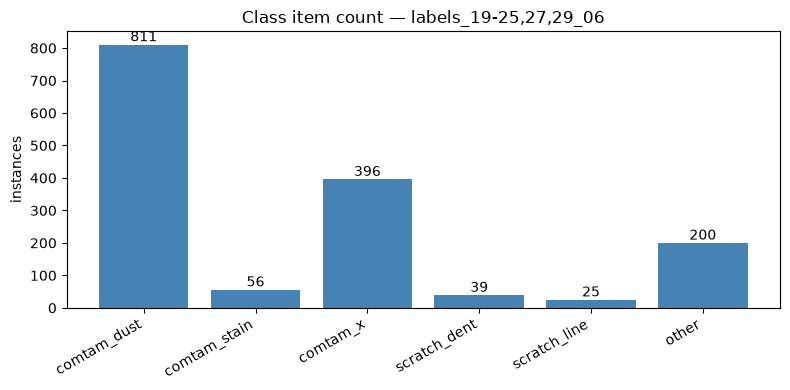

In [6]:
# bar chart
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df['class_name'], df['count'], color='steelblue')
ax.set_ylabel('instances')
ax.set_title('Class item count — labels_19-25,27,29_06')
for i, v in enumerate(df['count']):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(Path.cwd() / 'class_counts_19-25,27,29_06.png', dpi=120)
plt.show()